In [25]:
# 1. Import essential libraries
# cell : 1
import numpy as np
import pandas as pd
import time
import gc
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor as SklearnRegressor
from snapml import DecisionTreeRegressor as SnapRegressor

# 2. Suppress warnings for a clean output
warnings.filterwarnings('ignore')

# 3. Memory Optimization Helper Function
def memory_optimize(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype(np.float32)
        if df[col].dtype == 'int64':
            df[col] = df[col].astype(np.int32)
    return df


In [26]:
#cell : 2
# 1. Load the dataset
raw_data = pd.read_csv('yellow_tripdata_2019-06_1M.csv')
print(f"Total observations: {len(raw_data)}")

# 2. Clean data: focus on credit card tips and remove outliers
raw_data = raw_data[raw_data['tip_amount'] > 0]
raw_data = raw_data[(raw_data['tip_amount'] <= raw_data['fare_amount'])]
raw_data = raw_data[((raw_data['fare_amount'] >= 2) & (raw_data['fare_amount'] < 200))]

# 3. Drop target-related column and optimize memory
data = raw_data.drop(['total_amount'], axis=1)
del raw_data
gc.collect()

data = memory_optimize(data)
print(f"Observations after cleaning: {len(data)}")

Total observations: 1000000
Observations after cleaning: 682522


In [27]:
# cell : 3
# 1. Feature Engineering: Extracting temporal information
data['tpep_pickup_datetime'] = pd.to_datetime(data['tpep_pickup_datetime'])
data['tpep_dropoff_datetime'] = pd.to_datetime(data['tpep_dropoff_datetime'])

data['pickup_hour'] = data['tpep_pickup_datetime'].dt.hour
data['pickup_day'] = data['tpep_pickup_datetime'].dt.weekday
data['trip_time'] = (data['tpep_dropoff_datetime'] - data['tpep_pickup_datetime']).dt.total_seconds() / 60

# 2. Selecting relevant numeric features for the model
# We focus on quantitative variables to ensure model stability
numeric_data = data.select_dtypes(include=[np.number]).copy()

# 3. Data Imputation: Handling missing values by filling with zeros
# This ensures that the dataset remains complete for the normalization step
numeric_data.fillna(0, inplace=True)

# 4. Defining the Target variable (y) and Feature matrix (X)
y = numeric_data['tip_amount'].values
X = numeric_data.drop(columns=['tip_amount'], errors='ignore').values

# 5. Data Normalization: Scaling features using L1 normalization
# This prepares the data for the Decision Tree Regressor
from sklearn.preprocessing import Normalizer
normalizer = Normalizer(norm='l1')
X = normalizer.fit_transform(X)

# 6. Dataset Partitioning: 70% Training and 30% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Final Status Update
print(f"Preprocessing completed successfully.")
print(f"Total training samples: {X_train.shape[0]}")
print(f"Total features utilized: {X_train.shape[1]}")

Preprocessing completed successfully.
Total training samples: 477765
Total features utilized: 17


In [28]:
#cell : 4 
#  1. Scikit-Learn Decision Tree Regressor
# We initialize the regressor with a fixed depth for fair comparison
sklearn_dt = SklearnRegressor(max_depth=8, random_state=35)

# Record training time for Scikit-Learn
t0 = time.time()
sklearn_dt.fit(X_train, y_train)
sklearn_time = time.time() - t0
print(f"[Scikit-Learn] Training time: {sklearn_time:.5f} seconds")

# 2. Snap ML Decision Tree Regressor
# Snap ML utilizes multi-threading for faster processing (n_jobs)
snapml_dt = SnapRegressor(max_depth=8, random_state=45, n_jobs=4)

# Record training time for Snap ML
t0 = time.time()
snapml_dt.fit(X_train, y_train)
snapml_time = time.time() - t0
print(f"[Snap ML]      Training time: {snapml_time:.5f} seconds")

# 3. Calculate and display the speedup factor
training_speedup = sklearn_time / snapml_time
print(f"\n Performance Gain: Snap ML is {training_speedup:.2f}x faster than Scikit-Learn")

[Scikit-Learn] Training time: 10.58419 seconds
[Snap ML]      Training time: 0.60200 seconds

 Performance Gain: Snap ML is 17.58x faster than Scikit-Learn


In [29]:
#cell : 5 

# 1. Run inference (predictions) on the test dataset
sklearn_pred = sklearn_dt.predict(X_test)
snapml_pred = snapml_dt.predict(X_test)

# 2. Evaluate Mean Squared Error (Lower values indicate better performance)
sklearn_mse = mean_squared_error(y_test, sklearn_pred)
snapml_mse = mean_squared_error(y_test, snapml_pred)

print(f"--- Accuracy Evaluation ---")
print(f"[Scikit-Learn] MSE Score: {sklearn_mse:.4f}")
print(f"[Snap ML]      MSE Score: {snapml_mse:.4f}")

# Final confirmation
if abs(sklearn_mse - snapml_mse) < 0.05:
    print("\nConclusion: Both models provide comparable accuracy levels.")

--- Accuracy Evaluation ---
[Scikit-Learn] MSE Score: 1.6760
[Snap ML]      MSE Score: 1.6627

Conclusion: Both models provide comparable accuracy levels.


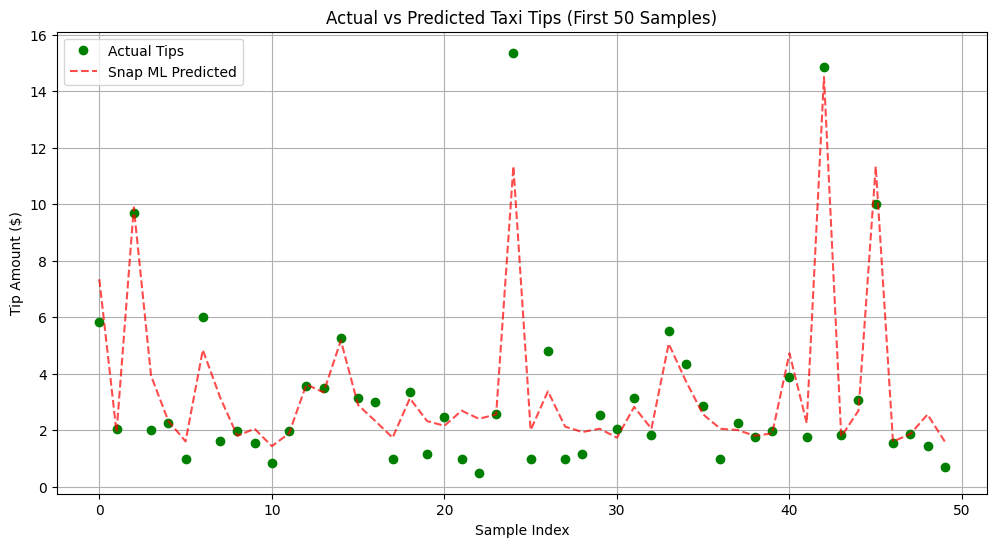

In [30]:
#cell : 6 
import matplotlib.pyplot as plt

# Plotting the first 50 samples to compare predictions vs actual values
plt.figure(figsize=(12, 6))
plt.plot(y_test[:50], label='Actual Tips', color='green', marker='o', linestyle='None')
plt.plot(snapml_pred[:50], label='Snap ML Predicted', color='red', linestyle='--', alpha=0.7)
plt.title('Actual vs Predicted Taxi Tips (First 50 Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Tip Amount ($)')
plt.legend()
plt.grid(True)
plt.show()